In [ ]:
!curl -L -o dataset.zip https://www.kaggle.com/api/v1/datasets/download/frankossai/natural-questions-dataset
!unzip -n -q /content/dataset.zip
!rm dataset.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  111M  100  111M    0     0  27.4M      0  0:00:04  0:00:04 --:--:-- 31.2M


In [ ]:
%pip install -q language-tool-python

In [ ]:
import pandas as pd
import re
from bs4 import BeautifulSoup
import language_tool_python
import random
from difflib import SequenceMatcher
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np

In [ ]:
df_base = pd.read_csv('/content/Natural-Questions-Base.csv', nrows=1_00)
df_base.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   question       100 non-null    object
 1   long_answers   54 non-null     object
 2   short_answers  38 non-null     object
dtypes: object(3)
memory usage: 2.5+ KB


In [ ]:
df_base = df_base.dropna()

In [ ]:
df_filtered = pd.read_csv('/content/Natural-Questions-Filtered.csv', nrows=1_00)
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   question       100 non-null    object
 1   long_answers   100 non-null    object
 2   short_answers  100 non-null    object
dtypes: object(3)
memory usage: 2.5+ KB


In [ ]:
def get_similarity(a, b):
    a_clean = "".join(str(a).split())
    b_clean = "".join(str(b).split())
    return SequenceMatcher(None, a_clean, b_clean).ratio()

class DataCleaner:
    def __init__(self):
        self.tool = language_tool_python.LanguageTool('en-US')

    def strip_html(self, text):
        soup = BeautifulSoup(text, "html.parser")
        return soup.get_text(separator=" ")

    def fix_spacing(self, text):
        text = re.sub(r'\s+([?.!,:;])', r'\1', text)
        text = re.sub(r'\(\s+', '(', text)
        text = re.sub(r'\s+\)', ')', text)
        text = re.sub(r'``\s+', '`` ', text)
        text = re.sub(r'\s+\'\'', " ''", text)
        text = re.sub(r'\s+', ' ', text).strip()
        return text

    def grammar_correction(self, text):
        matches = self.tool.check(text)
        return language_tool_python.utils.correct(text, matches)

    def clean_text(self, text):
        text = self.strip_html(text)
        text = self.fix_spacing(text)
        text = self.grammar_correction(text)
        return text

    def close(self):
        self.tool.close()

In [ ]:
cleaner = DataCleaner()

from tqdm import tqdm
tqdm.pandas()

df_base['long_answers_clean'] = df_base['long_answers'].progress_apply(lambda x: cleaner.clean_text(x))
df_base['short_answers_clean'] = df_base['short_answers'].progress_apply(lambda x: cleaner.clean_text(x))

100%|██████████| 38/38 [00:02<00:00, 17.14it/s]


In [ ]:
merged_df = pd.merge(
    df_base,
    df_filtered,
    on='question',
    suffixes=('_base', '_filtered')
)

In [ ]:
merged_df.columns

Index(['question', 'long_answers_base', 'short_answers_base',
       'long_answers_clean', 'short_answers_clean', 'long_answers_filtered',
       'short_answers_filtered'],
      dtype='object')

In [ ]:
sample_size = 10
check_df = merged_df[["long_answers_clean", "long_answers_filtered"]].sample(sample_size, random_state=2026)

In [ ]:
results = []
threshold = 0.95

for index, row in check_df.iterrows():
    base_text = row['long_answers_clean']
    expected_text = row['long_answers_filtered']

    actual_text = cleaner.clean_text(base_text)

    score = get_similarity(actual_text, expected_text)
    is_match = score >= threshold

    results.append({
        'expected': expected_text.strip(),
        'actual': actual_text.strip(),
        'score': score,
        'is_match': is_match
    })

matches = sum(1 for r in results if r['is_match'])
avg_score = sum(r['score'] for r in results) / sample_size

print(f"Matches (Score >= {threshold}): {matches}/{sample_size}")
print(f"Average Similarity Score: {avg_score:.4f}")

mismatches = [r for r in results if not r['is_match']]

if mismatches:
    print(f"--- Top 3 Worst Mismatches (Lowest Scores) ---")
    mismatches.sort(key=lambda x: x['score'], reverse=False)
    for m in mismatches[:3]:
        print(f"Score: {m['score']:.4f}")
        print(f"Question: {m['question']}")
        print(f"Expected: {m['expected']}")
        print(f"Actual:   {m['actual']}")
        print("-" * 30)
    print("\n")

    print(f"--- Top 3 Most Similar Mismatches (Highest Scores) ---")
    mismatches.sort(key=lambda x: x['score'], reverse=True)
    for m in mismatches[:3]:
        print(f"Score: {m['score']:.4f}")
        print(f"Question: {m['question']}")
        print(f"Expected: {m['expected']}")
        print(f"Actual:   {m['actual']}")
        print("-" * 30)
cleaner.close()

Matches (Score >= 0.95): 10/10
Average Similarity Score: 0.9911


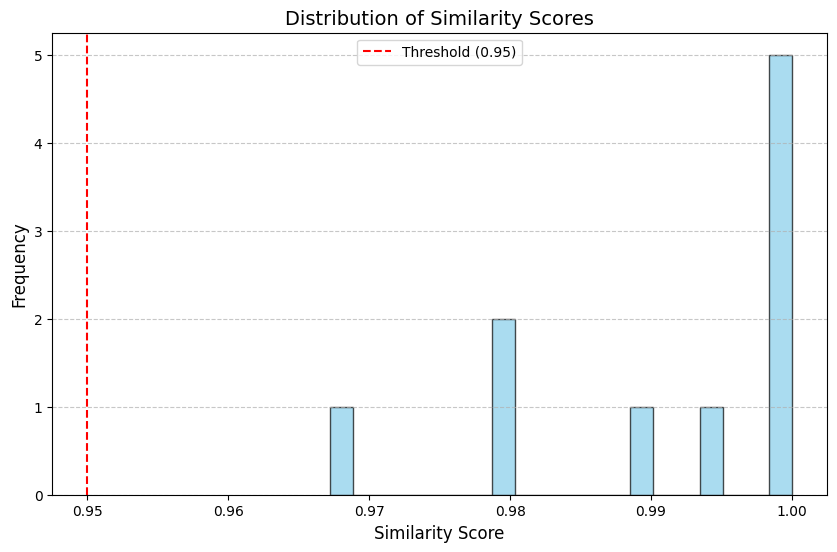

In [ ]:

scores = [r['score'] for r in results]

plt.figure(figsize=(10, 6))
plt.hist(scores, bins=20, color='skyblue', edgecolor='black', alpha=0.7)

plt.title(f'Distribution of Similarity Scores', fontsize=14)
plt.xlabel('Similarity Score', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.axvline(threshold, color='red', linestyle='dashed', linewidth=1.5, label=f'Threshold ({threshold})')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()

plt.show()


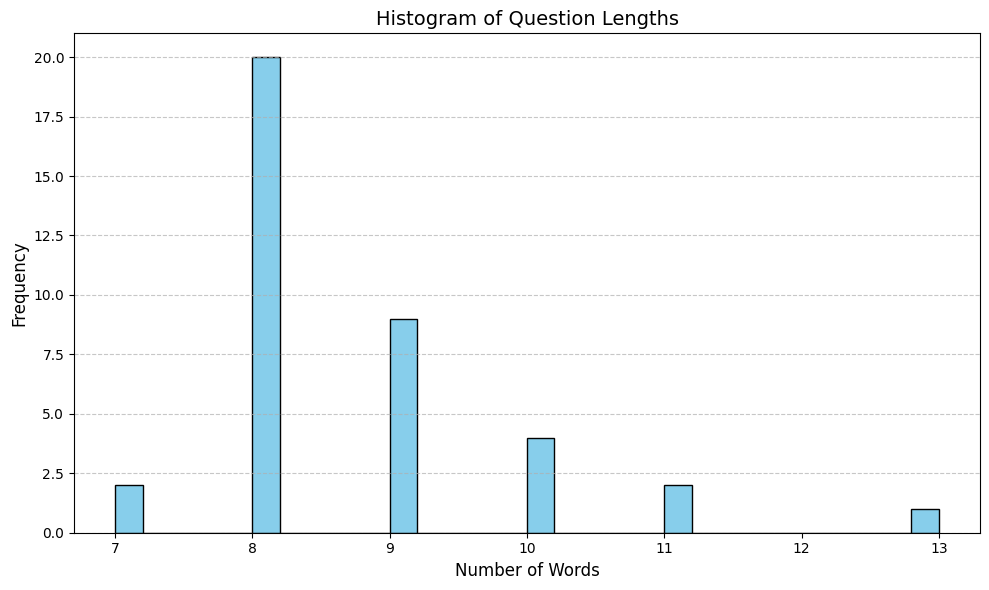

In [ ]:
answer_len = df_base['question'].str.split().str.len()
plt.figure(figsize=(10, 6))
answer_len.plot(kind='hist', bins=30, color='skyblue', edgecolor='black')
plt.title('Histogram of Question Lengths', fontsize=14)
plt.xlabel('Number of Words', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

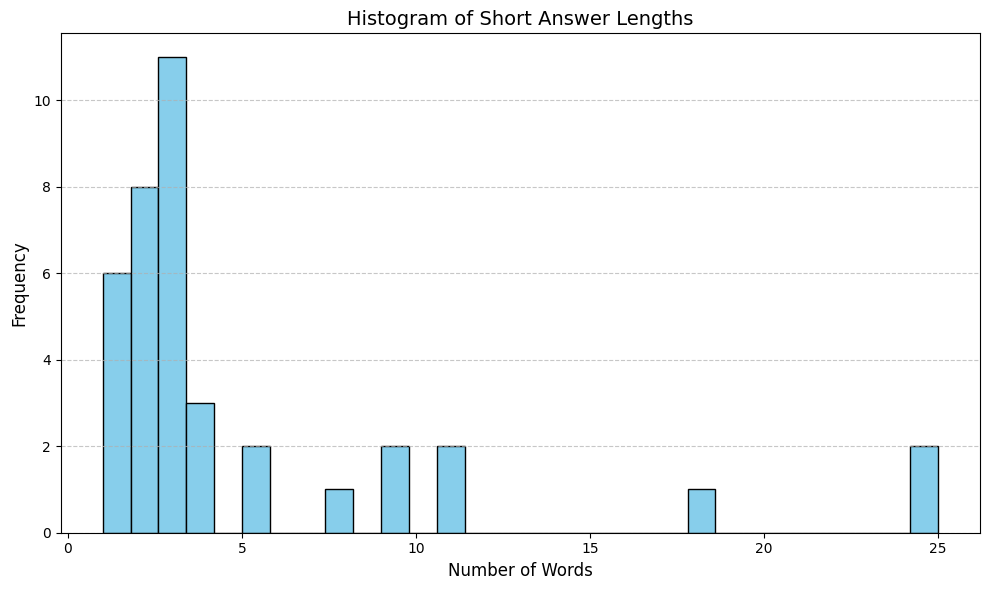

In [ ]:
answer_len = df_base['short_answers_clean'].str.split().str.len()
plt.figure(figsize=(10, 6))
answer_len.plot(kind='hist', bins=30, color='skyblue', edgecolor='black')
plt.title('Histogram of Short Answer Lengths', fontsize=14)
plt.xlabel('Number of Words', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

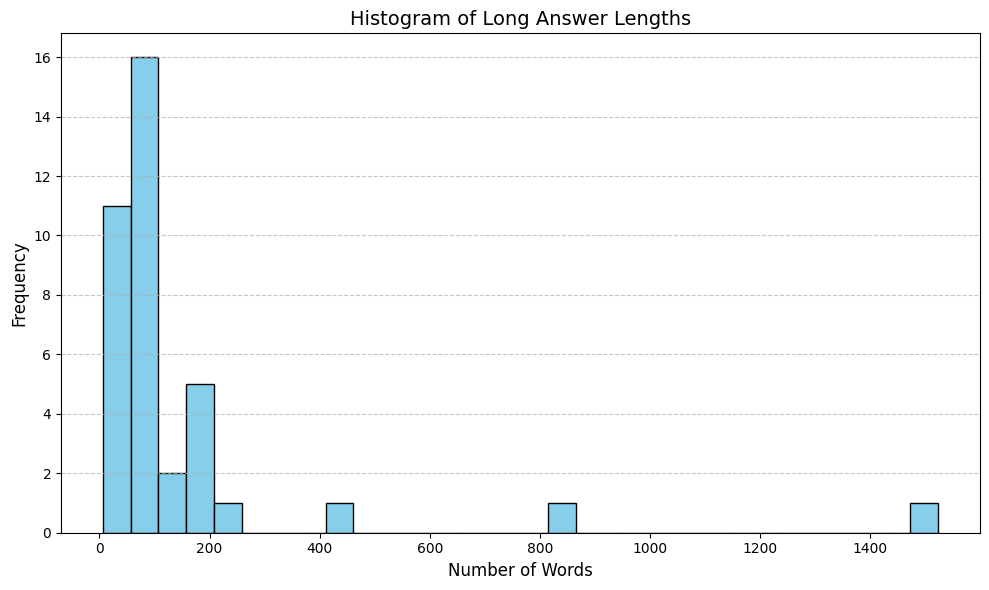

In [ ]:
answer_len = df_base['long_answers_clean'].str.split().str.len()
plt.figure(figsize=(10, 6))
answer_len.plot(kind='hist', bins=30, color='skyblue', edgecolor='black')
plt.title('Histogram of Long Answer Lengths', fontsize=14)
plt.xlabel('Number of Words', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Text Chunking

In [ ]:
def categorize_question_type(question, answer):
    q_lower = str(question).lower().strip()
    if q_lower.startswith('who'): return 'Person/Entity'
    elif q_lower.startswith('when'): return 'Date/Time'
    elif q_lower.startswith('where'): return 'Location'
    elif q_lower.startswith('why'): return 'Reason/Explanation'
    elif q_lower.startswith('how'): return 'Method/Quantity'
    elif q_lower.startswith('what'): return 'Object/Concept'
    elif q_lower.startswith('which'): return 'Choice/Identification'
    else: return 'Other'

def estimate_difficulty(question, answer):
    words = str(question).split()
    if len(words) <= 8:
        return 'Easy'
    elif len(words) <= 10:
        return 'Medium'
    else:
        return 'Hard'

def extract_domain(question, answer) -> str:
    if not hasattr(extract_domain, "_patterns"):

        domains = {
            'Pop Culture & Entertainment': [
                'movie', 'song', 'season', 'sings', 'sang', 'voice', 'show', 'series',
                'star', 'book', 'episode', 'episodes', 'film', 'music', 'story', 'actor',
                'actress', 'thrones', 'theme', 'singer', 'album', 'lyrics', 'potter', 'video', 'band'
            ],
            'Geography & Places': [
                'world', 'located', 'india', 'states', 'united', 'america', 'american',
                'city', 'south', 'country', 'earth', 'river', 'indian', 'england', 'north',
                'british', 'york', 'map', 'australia', 'canada', 'texas', 'capital', 'france',
                'island', 'china', 'africa', 'population', 'largest', 'sea', 'california', 'germany'
            ],
            'Sports & Competitions': [
                'won', 'cup', 'game', 'league', 'nba', 'win', 'football', 'games', 'team',
                'olympics', 'bowl', 'nfl', 'championship', 'baseball', 'player', 'wins',
                'basketball', 'scored', 'tournament', 'coach'
            ],
            'History & Government': [
                'war', 'president', 'state', 'national', 'battle', 'king', 'built',
                'government', 'law', 'court', 'constitution', 'act', 'rights', 'civil',
                'supreme', 'flag', 'minister', 'union', 'empire', 'bill', 'independence',
                'congress', 'federal', 'army', 'revolution', 'amendment', 'senate'
            ],
            'Science & Nature': [
                'body', 'water', 'air', 'system', 'human', 'anatomy', 'blood',
                'heart', 'cell', 'theory', 'sun', 'space', 'light', 'moon', 'cells', 'fire',
                'physics', 'chemistry', 'biology', 'scientist', 'equation', 'calculate', 'planet'
            ]
        }

        extract_domain._patterns = {
            domain: re.compile(r'\b(?:' + '|'.join(re.escape(kw) for kw in keywords) + r')\b', re.IGNORECASE)
            for domain, keywords in domains.items()
        }

    scores = Counter()
    for domain, pattern in extract_domain._patterns.items():
        matches = pattern.findall(question)
        if matches:
            scores[domain] = len(matches)

    if scores:
        return scores.most_common(1)[0][0]

    return 'General'

In [ ]:
df_base['question_type'] = df_base.apply(
    lambda row: categorize_question_type(row['question'], row['long_answers_clean']),
    axis=1
)

df_base['question_difficulty'] = df_base.apply(
    lambda row: estimate_difficulty(row['question'], row['long_answers_clean']),
    axis=1
)

df_base['question_domain'] = df_base.apply(
    lambda row: extract_domain(row['question'], row['long_answers_clean']),
    axis=1
)
df_base[['question', 'question_type', 'question_difficulty', 'question_domain']].head()

,question,question_type,question_difficulty,question_domain
0,which is the most common use of opt-in e-mail ...,Choice/Identification,Medium,General
1,how i.met your mother who is the mother,Method/Quantity,Easy,General
3,who had the most wins in the nfl,Person/Entity,Easy,Sports & Competitions
6,who played mantis guardians of the galaxy 2,Person/Entity,Easy,General
15,the nashville sound brought a polished and cos...,Other,Hard,Pop Culture & Entertainment


In [ ]:
df_base['question_type'].value_counts()

,count
question_type,
Person/Entity,13
Other,7
Date/Time,6
Object/Concept,5
Location,3
Method/Quantity,2
Choice/Identification,1
Reason/Explanation,1


In [ ]:
df_base['question_difficulty'].value_counts()

,count
question_difficulty,
Easy,22
Medium,13
Hard,3


In [ ]:
df_base['question_domain'].value_counts()

,count
question_domain,
General,14
Sports & Competitions,7
Pop Culture & Entertainment,6
Geography & Places,5
Science & Nature,3
History & Government,3


In [ ]:
!pip install -U langchain-text-splitters
from langchain_text_splitters import RecursiveCharacterTextSplitter

In [ ]:
import pandas as pd
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document

splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=50,
    length_function=len,
    is_separator_regex=False,
)

all_chunks_data = []

for index, row in df_base.iterrows():
    question = row['question']
    q_type = row['question_type']
    difficulty = row['question_difficulty']
    domain = row['question_domain']
    long_answer = row['long_answers_clean']
    short_answer = row['short_answers_clean']

    combined_text = f"[QUESTION]\n{question}\n-----\n[SHORT ANSWER]\n{short_answer}\n-----\n[LONG ANSWER]\n{long_answer}"

    custom_metadata = {
        "source_row_index": index,
        "question_type": q_type,
        "question_difficulty": difficulty,
        "question_domain": domain
    }

    doc = Document(page_content=combined_text, metadata=custom_metadata)

    chunk_docs = splitter.split_documents([doc])

    for i, chunk_doc in enumerate(chunk_docs):
        all_chunks_data.append({
            'chunk_id': f"{index}_{i}",
            'chunk_text': chunk_doc.page_content,
            'metadata': chunk_doc.metadata
        })

chunks_df = pd.DataFrame(all_chunks_data)
print(f"Created {len(chunks_df)} chunks from {len(df_base)} rows.")

print("\n--- Example Chunk Text ---")
print(chunks_df.iloc[0]['chunk_text'])

print("\n--- Example Attached Metadata ---")
print(chunks_df.iloc[0]['metadata'])

Created 109 chunks from 38 rows.

--- Example Chunk Text ---
[QUESTION]
which is the most common use of opt-in e-mail marketing
-----
[SHORT ANSWER]
A newsletter sent to an advertising firm's customers
-----
[LONG ANSWER]

--- Example Attached Metadata ---
{'source_row_index': 0, 'question_type': 'Choice/Identification', 'question_difficulty': 'Medium', 'question_domain': 'General'}


# faiss dataset

In [ ]:
!pip install -q sentence-transformers faiss-cpu
!pip install -U bitsandbytes>=0.46.1

import numpy as np
import faiss
from sentence_transformers import SentenceTransformer

model_name = 'BAAI/bge-m3'
embedding_model = SentenceTransformer(model_name)

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

In [ ]:
import numpy as np
import faiss
import torch
from transformers import pipeline
from functools import lru_cache

class DocumentIndexingPipeline:
    def __init__(self, embedding_model, dimension=1024, max_history_turns=3):
        self.embedding_model = embedding_model
        # Initialize FAISS index
        self.index = faiss.IndexIDMap(faiss.IndexFlatL2(dimension))
        self.doc_store = {}
        self._next_id = 0
        self.conversation_history = []
        self.max_history_turns = max_history_turns

        # Model Setup - Ensure this is assigned to self.pipe
        model_id = "unsloth/Llama-3.2-1B-Instruct"
        self.pipe = pipeline(
            "text-generation",
            model=model_id,
            dtype=torch.bfloat16,
            device_map="auto",
        )
    @lru_cache(maxsize=50)
    def _cached_llm_expansion(self, processed_query):
        messages = [
            {
                "role": "system",
                "content": (
                    "You are an expert search query rewriter. Your task is to transform the user's input "
                    "into a single, optimized search query expansion; Do not repeat the user input.\n\n"
                    "Rules:\n"
                    "1. Use relevant synonyms and semantic variations.\n"
                    "2. Respond ONLY with the rewritten query."
                )
            },
            {
                "role": "user",
                "content": f"Input: {processed_query}"
            },
        ]

        outputs = self.pipe(messages)
        output = outputs[0]["generated_text"][-1]["content"].strip()

        if '"' in output:
            output = output.split('"')[1]
        return output


    def add_to_history(self, role, text):
        """Adds a turn to the conversation history."""
        self.conversation_history.append({"role": role, "text": text})

        max_messages = self.max_history_turns * 2
        if len(self.conversation_history) > max_messages:
            self.conversation_history = self.conversation_history[-max_messages:]

    def clear_history(self):
        self.conversation_history = []

    def add_documents(self, chunks_df):
        texts = chunks_df['chunk_text'].tolist()
        print("Generating embeddings for indexing...")
        embeddings = self.embedding_model.encode(
            texts,
            batch_size=32,
            show_progress_bar=True,
            normalize_embeddings=True).astype('float32')

        ids = np.arange(self._next_id, self._next_id + len(texts), dtype=np.int64)
        self.index.add_with_ids(embeddings, ids)

        for i, idx in enumerate(ids):
            row = chunks_df.iloc[i]
            self.doc_store[int(idx)] = {
                "chunk_id": row['chunk_id'],
                "text": row['chunk_text'],
                "metadata": row.get('metadata', {}) # Fallback if metadata missing
            }

        self._next_id += len(texts)
        print(f"Successfully indexed {len(texts)} documents. Total in index: {self.index.ntotal}")

    def _query_preprocessing(self, query):
        query = query.lower()
        if not self.conversation_history:
            return query

        history_str = " | ".join(
            [f"{msg['role'].lower()}: {msg['text'].lower()}" for msg in self.conversation_history]
        )
        return f"context: {history_str} | current query: {query}"

    def _query_expansion(self, query):
        processed_query = self._query_preprocessing(query)
        expanded_term = self._cached_llm_expansion(processed_query)
        final_query = f"{query}\n{expanded_term}"
        return final_query

    def search(self, query, k=1):

        expanded_query = self._query_expansion(query)
        print(f"Searching for: {expanded_query}")

        query_vector = self.embedding_model.encode([expanded_query]).astype('float32')
        distances, indices = self.index.search(query_vector, k)

        results = []
        for i, idx in enumerate(indices[0]):
            if idx != -1:
                doc = self.doc_store[int(idx)]
                results.append({
                    "score": float(distances[0][i]),
                    "chunk_id": doc["chunk_id"],
                    "text": doc["text"],

                    "metadata": doc["metadata"]
                })
        return results

In [ ]:
rag_pipeline = DocumentIndexingPipeline(embedding_model)
rag_pipeline.add_documents(chunks_df)

Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

Generating embeddings for indexing...


Batches:   0%|          | 0/4 [00:00<?, ?it/s]

Successfully indexed 109 documents. Total in index: 109


In [ ]:
query = "Who was the first person in space?"

search_results = rag_pipeline.search(query, k=1)
print(search_results)

Expanded Query: Who was the first person in space?
What a historic moment... The first person in space was Yuri Gagarin, a Soviet cosmonaut.
Searching for: Who was the first person in space?
What a historic moment... The first person in space was Yuri Gagarin, a Soviet cosmonaut.
[{'score': 0.7985127568244934, 'chunk_id': '80_0', 'text': '[QUESTION]\nwho is the first person who went to moon\n-----\n[SHORT ANSWER]\nNeil Alden Armstrong\n-----\n[LONG ANSWER]\nNeil Alden Armstrong (August 5, 1930 -- August 25, 2012) was an American astronaut and aeronautical engineer who was the first person to walk on the Moon. He was also a naval aviator, test pilot, and university professor.', 'metadata': {'source_row_index': 80, 'question_type': 'Person/Entity', 'question_difficulty': 'Medium', 'question_domain': 'Science & Nature'}}]


In [ ]:
for result in search_results:
    print(f"Distance Score: {result['score']:.2f}")
    print(f"Domain: {result['metadata']['question_domain']}")
    print(f"Difficulty: {result['metadata']['question_difficulty']}")
    print(f"Question Type: {result['metadata']['question_type']}")
    print(f"Source Row Index: {result['metadata']['source_row_index']}")
    print(f"Text snippet:\n{result['text']}")

Distance Score: 0.80
Domain: Science & Nature
Difficulty: Medium
Question Type: Person/Entity
Source Row Index: 80
Text snippet:
[QUESTION]
who is the first person who went to moon
-----
[SHORT ANSWER]
Neil Alden Armstrong
-----
[LONG ANSWER]
Neil Alden Armstrong (August 5, 1930 -- August 25, 2012) was an American astronaut and aeronautical engineer who was the first person to walk on the Moon. He was also a naval aviator, test pilot, and university professor.


In [ ]:
import os
import json
from openai import OpenAI
from google.colab import userdata

client = OpenAI(api_key=userdata.get('OPENAI_API_KEY'))


def generate_answer(query, search_results):

    context_text = ""
    for result in search_results:
        context_text += (
            f"Distance Score: {result['score']:.2f}\n"
            f"Domain: {result['metadata']['question_domain']}\n"
            f"Difficulty: {result['metadata']['question_difficulty']}\n"
            f"Question Type: {result['metadata']['question_type']}\n"
            f"Source Row Index: {result['metadata']['source_row_index']}\n"
            f"Text snippet:\n{result['text']}\n"
            "---"
        )

    response_schema = {
        "type": "json_schema",
        "json_schema": {
            "name": "qa_response",
            "strict": True,
            "schema": {
                "type": "object",
                "properties": {
                    "answer": {
                        "type": "string",
                        "description": "The detailed answer based strictly on context."
                    },
                    "confidence": {
                        "type": "number",
                        "description": "A confidence score between 0.0 and 1.0."
                    }
                },
                "required": ["answer", "confidence"],
                "additionalProperties": False
            }
        }
    }

    system_prompt = "You are a highly capable assistant. Answer using ONLY the provided context."
    user_prompt = f"Context Information:\n{context_text}\n\nUser Question: {query}"

    completion = client.chat.completions.create(
        model="gpt-5-mini",
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_prompt}
        ],
        response_format=response_schema,
    )

    response_data = json.loads(completion.choices[0].message.content)
    answer = response_data["answer"]
    confidence = response_data["confidence"]

    if confidence < 0.5:
        return handle_fallback("The context provided didn't contain enough reliable information.")

    return {
        "status": "success",
        "answer": answer,
        "confidence": confidence
    }

def handle_fallback(reason):
    return {
        "status": "fallback",
        "answer": "I'm sorry, but I don't have enough reliable information in my current context to answer your question confidently.",
        "confidence": 0.0,
        "fallback_reason": reason
    }

In [ ]:
if __name__ == "__main__":
    query = 'who is the first person who went to the moon'

    rag_results = rag_pipeline.search(query, k=1)

    result = generate_answer(query, rag_results)

    print("Status:", result.get("status"))
    print("Answer:", result.get("answer"))
    print("Confidence Score:", result.get("confidence"))

    if result.get("status") == "fallback":
        print("Reason:", result["fallback_reason"])

Expanded Query: who is the first person who went to the moon
Who was the first person to walk on the moon?
Searching for: who is the first person who went to the moon
Who was the first person to walk on the moon?
Status: success
Answer: Neil Alden Armstrong was the first person to walk on the Moon. (August 5, 1930 – August 25, 2012) He was an American astronaut and aeronautical engineer, and also served as a naval aviator, test pilot, and university professor.
Confidence Score: 0.9


In [ ]:
!pip install -q rouge-score

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer

class PipelineEvaluator:
    def __init__(self):
        self.metrics_log = []
        self.rouge_scorer = rouge_scorer.RougeScorer(['rouge1', 'rougeL'], use_stemmer=True)
        self.bleu_smoother = SmoothingFunction().method1

    def evaluate_retrieval(self, expected_source_id, retrieved_chunks, k=1):
        """
        Calculates Precision@K and Recall@K.
        Assumes there is exactly 1 relevant document (the original source row).
        """
        retrieved_ids = [chunk['metadata']['source_row_index'] for chunk in retrieved_chunks[:k]]

        is_relevant_retrieved = int(expected_source_id in retrieved_ids)

        precision_at_k = is_relevant_retrieved / k
        recall_at_k = is_relevant_retrieved / 1.0

        return precision_at_k, recall_at_k

    def evaluate_generation(self, reference_answer, generated_answer):
        """Calculates BLEU and ROUGE scores for the LLM output."""
        if not generated_answer or not reference_answer:
            return 0.0, 0.0, 0.0

        ref_tokens = str(reference_answer).split()
        gen_tokens = str(generated_answer).split()

        bleu_score = sentence_bleu([ref_tokens], gen_tokens, smoothing_function=self.bleu_smoother)

        rouge_scores = self.rouge_scorer.score(str(reference_answer), str(generated_answer))
        rouge1 = rouge_scores['rouge1'].fmeasure
        rougeL = rouge_scores['rougeL'].fmeasure

        return bleu_score, rouge1, rougeL

    def track_query(self, query_id, query_text, expected_source_id, reference_answer, search_fn, generate_fn):
        """Executes a single pipeline run and logs all performance metrics."""

        # 1. Benchmark Retrieval
        t0 = time.time()
        search_results = search_fn(query_text)
        retrieval_time = time.time() - t0

        precision, recall = self.evaluate_retrieval(expected_source_id, search_results, k=1)

        # 2. Benchmark Generation
        t1 = time.time()
        gen_result = generate_fn(query_text, search_results)
        generation_time = time.time() - t1

        generated_text = gen_result.get("answer", "")
        confidence = gen_result.get("confidence", 0.0)

        # 3. Evaluate Quality
        bleu, rouge1, rougeL = self.evaluate_generation(reference_answer, generated_text)

        total_time = retrieval_time + generation_time

        # 4. Log Metrics
        self.metrics_log.append({
            "query_id": query_id,
            "retrieval_time_sec": retrieval_time,
            "generation_time_sec": generation_time,
            "total_time_sec": total_time,
            "precision@1": precision,
            "recall@1": recall,
            "bleu_score": bleu,
            "rouge1_f1": rouge1,
            "rougeL_f1": rougeL,
            "confidence": confidence
        })

    def generate_report(self):
        """Compiles logs into a DataFrame and prints summary statistics."""
        df = pd.DataFrame(self.metrics_log)

        total_queries = len(df)
        total_time = df['total_time_sec'].sum()
        throughput = total_queries / total_time if total_time > 0 else 0

        print("--- RAG Pipeline Performance Report ---")
        print(f"Total Queries Processed: {total_queries}")
        print(f"System Throughput: {throughput:.2f} queries/sec")
        print("\n--- Average Latency ---")
        print(f"Retrieval latency: {df['retrieval_time_sec'].mean():.4f}s")
        print(f"Generation latency: {df['generation_time_sec'].mean():.4f}s")
        print(f"Total latency per query: {df['total_time_sec'].mean():.4f}s")
        print("\n--- Retrieval Accuracy ---")
        print(f"Precision@1: {df['precision@1'].mean():.4f}")
        print(f"Recall@1: {df['recall@1'].mean():.4f}")
        print("\n--- Generation Quality ---")
        print(f"BLEU Score: {df['bleu_score'].mean():.4f}")
        print(f"ROUGE-1 F1: {df['rouge1_f1'].mean():.4f}")
        print(f"ROUGE-L F1: {df['rougeL_f1'].mean():.4f}")
        print(f"Average Confidence: {df['confidence'].mean():.4f}")
        print("---------------------------------------")

        return df

    def plot_benchmarks(self, df):
        """Generates visual performance reports."""
        # Adjusted figsize for a single plot, and changed 'axes' to 'ax'
        fig, ax = plt.subplots(figsize=(10, 6))

        ax.hist(df['rougeL_f1'], bins=10, alpha=0.7, color='green', edgecolor='black', label='ROUGE-L')
        ax.hist(df['bleu_score'], bins=10, alpha=0.7, color='blue', edgecolor='black', label='BLEU')
        ax.set_title('Distribution of Generation Scores')
        ax.set_ylabel('Frequency')
        ax.set_xlabel('Score')
        ax.legend()
        plt.tight_layout()
        plt.show()

Starting pipeline benchmark...
Expanded Query: who has the most followers on instagram in the world
Who has the most followers on Instagram worldwide
Searching for: who has the most followers on instagram in the world
Who has the most followers on Instagram worldwide
Expanded Query: who is the first person who went to moon
Who is the first person to walk on the moon?
Searching for: who is the first person who went to moon
Who is the first person to walk on the moon?
--- RAG Pipeline Performance Report ---
Total Queries Processed: 2
System Throughput: 0.16 queries/sec

--- Average Latency ---
Retrieval latency: 0.9872s
Generation latency: 5.2584s
Total latency per query: 6.2455s

--- Retrieval Accuracy ---
Precision@1: 1.0000
Recall@1: 1.0000

--- Generation Quality ---
BLEU Score: 0.4620
ROUGE-1 F1: 0.4805
ROUGE-L F1: 0.4805
Average Confidence: 0.4500
---------------------------------------


TypeError: 'Axes' object is not subscriptable

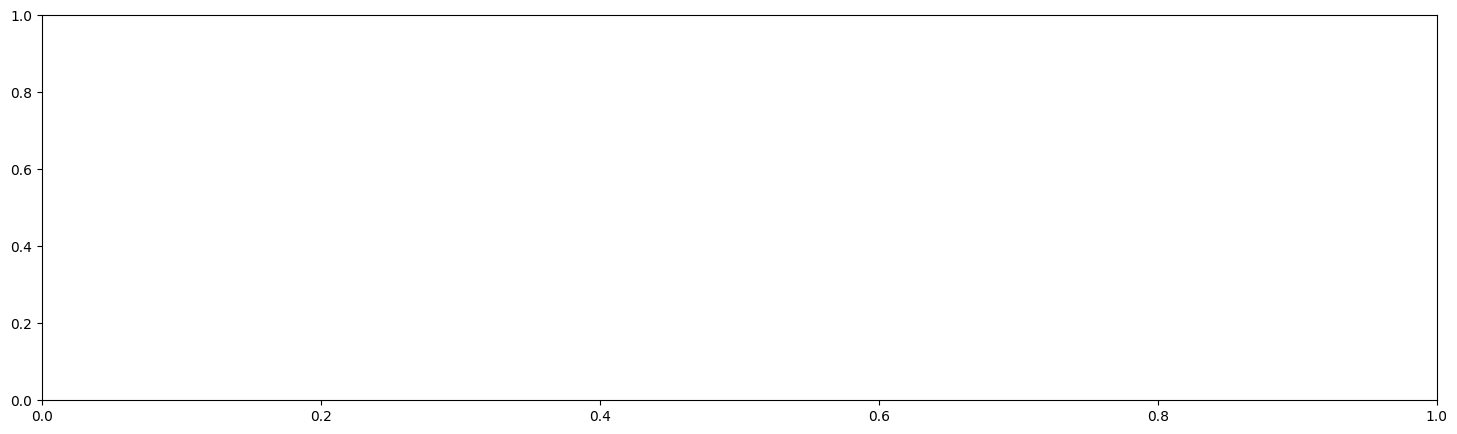

In [ ]:
evaluator = PipelineEvaluator()

test_df = df_base.sample(2, random_state=2026)

print("Starting pipeline benchmark...")

for index, row in test_df.iterrows():
    query_text = row['question']
    expected_source = index
    reference_answer = row['long_answers_clean']

    # Track the query through the pipeline
    evaluator.track_query(
        query_id=index,
        query_text=query_text,
        expected_source_id=expected_source,
        reference_answer=reference_answer,
        search_fn=lambda q: rag_pipeline.search(q, k=1),
        generate_fn=lambda q, ctx: generate_answer(q, ctx)
    )

metrics_df = evaluator.generate_report()
evaluator.plot_benchmarks(metrics_df)